In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

np.random.seed(42)

In [ ]:
n = 500

depts = np.random.choice(['Sales', 'IT', 'HR', 'Marketing'], size=n)
age = np.random.normal(32, 7, n).astype(int)
experience = np.random.normal(5, 3, n).round(1)
projects = np.random.poisson(8, n)
hours = np.random.normal(40, 8, n).round(1)
salary = 50000 + experience * 3000 + np.random.normal(0, 15000, n)

df = pd.DataFrame({
    'Department': depts,
    'Age': age,
    'Experience': experience,
    'Projects': projects,
    'Hours': hours,
    'Salary': salary
})

In [ ]:
for i in range(len(df)):
    if df.loc[i, 'Department'] == 'IT':
        df.loc[i, 'Salary'] = df.loc[i, 'Salary'] * 1.25
    elif df.loc[i, 'Department'] == 'Marketing':
        df.loc[i, 'Salary'] = df.loc[i, 'Salary'] * 1.1

for i in range(len(df)):
    if df.loc[i, 'Experience'] > 7:
        df.loc[i, 'Salary'] = df.loc[i, 'Salary'] * 1.15

In [ ]:
df['Age'] = df['Age'].astype(object)
df['Experience'] = df['Experience'].astype(object)
df['Projects'] = df['Projects'].astype(object)
df['Hours'] = df['Hours'].astype(object)
df['Salary'] = df['Salary'].round(0)

df.loc[10, 'Age'] = -5
df.loc[50, 'Experience'] = 'many'
df.loc[100, 'Salary'] = None
df.loc[200, 'Hours'] = None
df.loc[300, 'Projects'] = 'lot'

In [ ]:
print("=== Данные ===")
print(df.head(10))
print(f"\nРазмер: {df.shape}")
print(f"\nПропуски:\n{df.isnull().sum()}")

=== Данные ===
  Department Age Experience Projects Hours    Salary
0         HR  26        7.1        7  45.8   73130.0
1  Marketing  21        6.3       11  40.9   56007.0
2      Sales  28        3.9       11  48.1   88472.0
3         HR  37        8.5        8  44.1   87057.0
4         HR  33        1.8       10  40.2   52027.0
5  Marketing  23        6.8        8  37.6   62115.0
6      Sales  33        6.8        5  39.4  114435.0
7      Sales  34        4.1        5  14.6   46200.0
8         HR  25        6.0       12  41.7   61567.0
9         IT  33        1.2        7  36.1   74797.0

Размер: (500, 6)

Пропуски:
Department    0
Age           0
Experience    0
Projects      0
Hours         1
Salary        1
dtype: int64


In [ ]:
def clean_numeric(x):
    if pd.isna(x):
        return np.nan 
    x = str(x).strip().lower()
    x = pd.to_numeric(x, errors='coerce')
    if x == '':
        return np.nan 
    return x 

def clean_dataframe(df, mapping_col):
    df = df.copy()
    for col, func in mapping_col.items():
        if col in df.columns:
            df[col] = df[col].apply(func)
    return df

mapping = {
    'Age' : clean_numeric,
    'Experience' : clean_numeric,
    'Projects' : clean_numeric,
    'Hours' : clean_numeric,
    'Salary' : clean_numeric
}



clean_df = clean_dataframe(df, mapping)
clean_df

,Department,Age,Experience,Projects,Hours,Salary
0,HR,26,7.1,7.0,45.8,73130.0
1,Marketing,21,6.3,11.0,40.9,56007.0
2,Sales,28,3.9,11.0,48.1,88472.0
3,HR,37,8.5,8.0,44.1,87057.0
4,HR,33,1.8,10.0,40.2,52027.0
...,...,...,...,...,...,...
495,HR,35,0.3,6.0,43.2,56871.0
496,HR,23,2.0,4.0,42.9,61919.0
497,Marketing,36,7.8,10.0,44.0,84772.0
498,Sales,30,2.1,13.0,42.3,63057.0


In [ ]:
print(clean_df.isnull().sum())

Department    0
Age           0
Experience    1
Projects      1
Hours         1
Salary        1
dtype: int64


In [ ]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Department  500 non-null    str    
 1   Age         500 non-null    int64  
 2   Experience  499 non-null    float64
 3   Projects    499 non-null    float64
 4   Hours       499 non-null    float64
 5   Salary      499 non-null    float64
dtypes: float64(4), int64(1), str(1)
memory usage: 23.6 KB


In [ ]:

salary_dep = clean_df.groupby('Department')['Salary'].mean()
exp_dep = clean_df.groupby('Department')['Experience'].mean()
stat_df = clean_df.groupby('Department')['Hours'].describe()
print(salary_dep, exp_dep, stat_df)

Department
HR           67443.239669
IT           86642.916667
Marketing    74784.250000
Sales        69488.581967
Name: Salary, dtype: float64 Department
HR           5.182645
IT           5.257407
Marketing    5.437838
Sales        5.350820
Name: Experience, dtype: float64             count       mean       std   min     25%    50%     75%   max
Department                                                               
HR          121.0  39.702479  8.075503  14.6  34.500  40.20  44.800  63.3
IT          108.0  38.918519  7.200638  22.2  34.175  38.90  42.850  64.9
Marketing   148.0  40.801351  7.714956  21.4  35.975  40.20  45.550  62.0
Sales       122.0  39.827869  8.640796  14.6  34.100  40.35  45.475  64.6


In [ ]:
hours_std = clean_df.groupby('Department')['Hours'].std()
hours_std

Department
HR           8.075503
IT           7.200638
Marketing    7.714956
Sales        8.640796
Name: Hours, dtype: float64

In [ ]:

it_df = df[df['Department']=='IT']['Salary']
sales_df = df[df['Department']=='Sales']['Salary']

t, p_value = stats.ttest_ind(it_df, sales_df)
print(f'P-value {p_value:.4f} T-test {t:.4f}')
sign = 'Разница значима - зарплаты разные' if p_value < 0.05 else 'Разница незначима - зарплаты одинаковые или несильно отличаются'
print(sign)

P-value 0.0000 T-test 6.0201
Разница значима - зарплаты разные


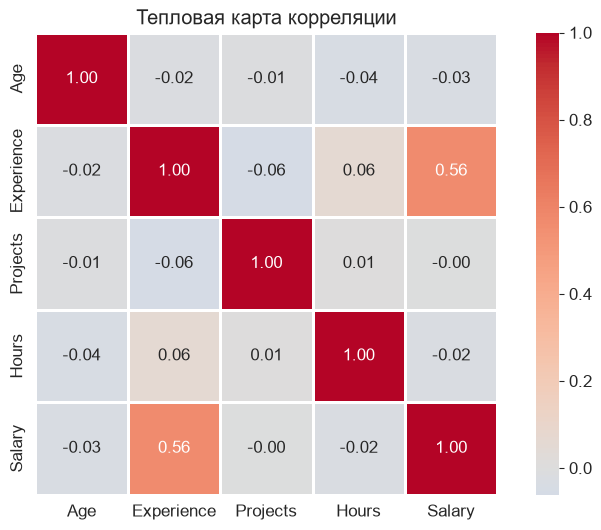

In [ ]:

matrix_cor = clean_df[['Age','Experience','Projects','Hours','Salary']].corr()
sns.heatmap(matrix_cor, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=1, square=True)
plt.title('Тепловая карта корреляции')
plt.show()


In [ ]:

r,p = stats.pearsonr(clean_df['Experience'].dropna(), clean_df['Salary'].dropna())
print(f'R {r:.7f} P-value {p:.7f}')
sign = 'Корреляция значима' if p < 0.05 else 'Корреляция незначима'
print(sign)

R 0.5075505 P-value 0.0000000
Корреляция значима


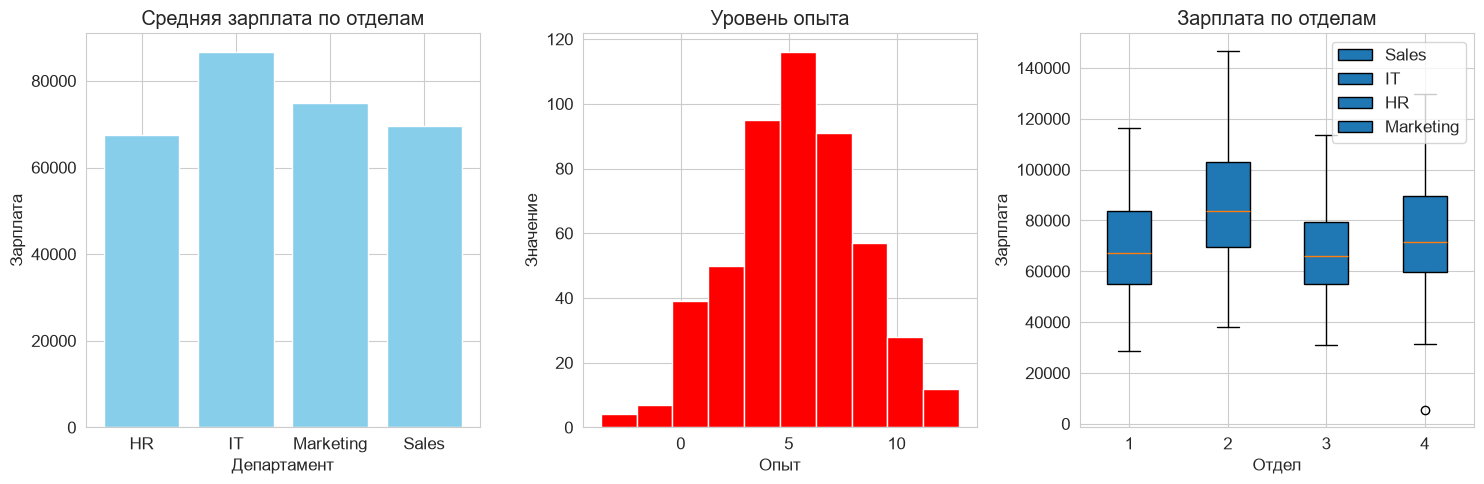

In [ ]:

fig, axes = plt.subplots(1, 3, figsize = (15, 5))

axes[0].bar(salary_dep.index, salary_dep.values, color='skyblue')
axes[0].set_title('Средняя зарплата по отделам')
axes[0].set_xlabel('Департамент')
axes[0].set_ylabel('Зарплата')

axes[1].hist(clean_df['Experience'], color='red')
axes[1].set_title('Уровень опыта')
axes[1].set_xlabel('Опыт')
axes[1].set_ylabel('Значение')

departments = ['Sales', 'IT', 'HR', 'Marketing']
data = [clean_df[clean_df['Department'] == dept]['Salary'].dropna() for dept in departments]
axes[2].boxplot(data,label=departments, patch_artist=True)
axes[2].set_title('Зарплата по отделам')
axes[2].set_xlabel('Отдел')
axes[2].set_ylabel('Зарплата')
axes[2].legend()

plt.tight_layout()
plt.show()